## **Домашнее задание #3: исследование KNN**
Цель задания — самостоятельно метод k-ближайших соседей (KNN) на реальном датасете и сравнить его с несколькими базовыми
моделями.



# Блок 1
Дата сет - Iris Species
https://www.kaggle.com/datasets/uciml/iris

# Блок 2
подключение библиотек. краткий EDA по датасету

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.spatial.distance import cosine
import pandas as pd
import time

In [137]:
df = pd.read_csv("Iris.csv")

print("Содержимое:\n")
print(df.head(5))

print("\n\nРазмеры:\n")
print(df.shape)

print("\n\nТипы признаков:\n")
print(df.dtypes)

print("\n\nБазовые статистики:\n")
print(df.describe())

print("\n\nПропуски:\n")
print(df.isnull().sum())

species = df['Species'].value_counts()
print("\n\nРаспределение классов:\n")
print(species)

Содержимое:

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


Размеры:

(150, 6)


Типы признаков:

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


Базовые статистики:

               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.7

Датасет Iris можно сказать идеален. Заполнение пропусков и кодирование категориальных признаков не требуется. Split и масштабирование будут ниже

# Блок 3 Подготовка данных

In [138]:
x = df.drop('Species', axis= 1)
x = x.drop('Id', axis = 1)
y = df['Species']
#в ходе экспериментов выяснил что требуется удалять ID! иначе точность выше

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify= y)

scale = StandardScaler()

x_train_scaled = scale.fit_transform(x_train);
x_test_scaled = scale.transform(x_test);

# Вопросы по ходу работы:

## 1. Почему масштабирование важно для KNN?
Без масштабирования признаки хранящие в себе более большие числа будут критически искажать реальное расстояние между объектами, ровно как и признаки хранящие в себе более маленькие числа не будут в достаточной мере влиять на расстояние

### 2. Почему нельзя подбирать параметры на тестовой выборке?
Вопрос тревиален. Модель будет переобучена под конкретный пример(тестовый пример)

# Блок 4-5 Обучение KNN. Подбор гиперпараметров

In [139]:
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'cosine']
}

grid_search = GridSearchCV(knn, grid, cv = 5, scoring = 'accuracy')
grid_search.fit(x_train_scaled, y_train)

print("Лучшие параметры:", grid_search.best_params_)



best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("\nТочность на тестовой выборке\n")
print(f"{test_accuracy:.4f}")

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

Точность на тестовой выборке

0.9333


In [140]:
results = pd.DataFrame(grid_search.cv_results_)

top = results.nlargest(10, 'mean_test_score')[['params', 'mean_test_score']]
print("\n10 лучших комбинаций параметров:\n")
for i, row in top.iterrows():
    print(f"{row['mean_test_score']:.4f} - {row['params']}")

print("\nвлияние k на accuracy\n")
k_scores = results.groupby('param_n_neighbors')['mean_test_score'].mean()
for k, score in k_scores.items():
    print(f"k={k}: {score:.4f}")

print("\nвлияние weights на accuracy\n")
weights_scores = results.groupby('param_weights')['mean_test_score'].mean()
for w, score in weights_scores.items():
    print(f"{w}: {score:.4f}")

print("\nвлияние metrics на accuracy\n")
metrics_scores = results.groupby('param_metric')['mean_test_score'].mean()
for m, score in metrics_scores.items():
    print(f"{m}: {score:.4f}")

print("\n")




10 лучших комбинаций параметров:

0.9667 - {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
0.9667 - {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
0.9667 - {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
0.9667 - {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
0.9667 - {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
0.9583 - {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
0.9583 - {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
0.9583 - {'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'distance'}
0.9583 - {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
0.9583 - {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

влияние k на accuracy

k=1: 0.9222
k=3: 0.9389
k=5: 0.9444
k=7: 0.9375
k=9: 0.9417
k=11: 0.9403
k=13: 0.9375
k=15: 0.9361

влияние weights на accuracy

distance: 0.9441
uniform: 0.9306

влияние metrics на accuracy

cosine: 0

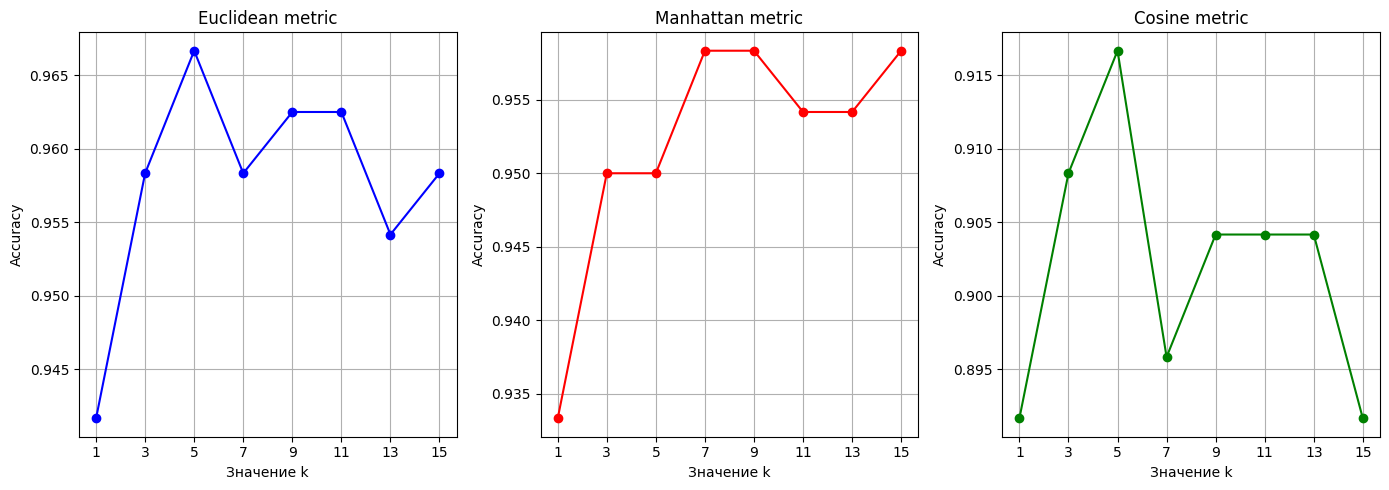

In [141]:
fig, ax  = plt.subplots(1, 3, figsize=(14, 5))

mask = results['param_metric'] == 'euclidean' #создаем маску для выбора только тех где значение metric равно заданному
data = results[mask].groupby('param_n_neighbors')['mean_test_score'].mean()
ax[0].plot(data.index, data.values, 'bo-')
ax[0].set_title('Euclidean metric')
ax[0].set_xlabel('Значение k')
ax[0].set_ylabel('Accuracy')
ax[0].set_xticks(data.index)
ax[0].grid(True)

mask = results['param_metric'] == 'manhattan'
data = results[mask].groupby('param_n_neighbors')['mean_test_score'].mean()
ax[1].plot(data.index, data.values, 'ro-')
ax[1].set_title('Manhattan metric')
ax[1].set_xlabel('Значение k')
ax[1].set_ylabel('Accuracy')
ax[1].set_xticks(data.index)
ax[1].grid(True)

mask = results['param_metric'] == 'cosine'
data = results[mask].groupby('param_n_neighbors')['mean_test_score'].mean()
ax[2].plot(data.index, data.values, 'go-')
ax[2].set_title('Cosine metric')
ax[2].set_xlabel('Значение k')
ax[2].set_ylabel('Accuracy')
ax[2].set_xticks(data.index)
ax[2].grid(True)

plt.tight_layout()
plt.show()

## Confusion matrix

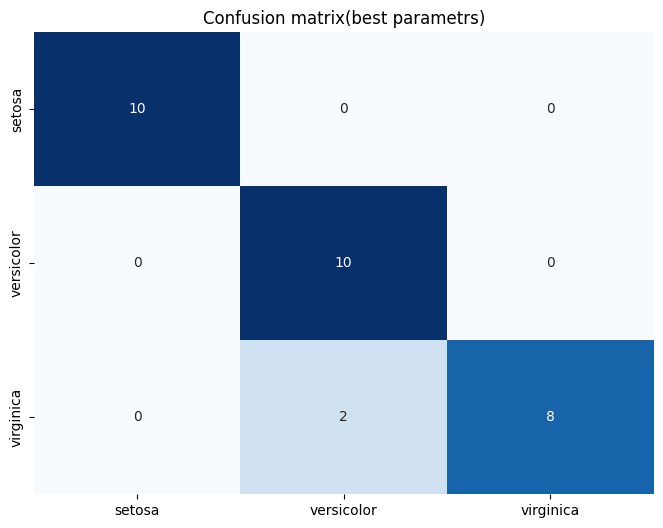

In [142]:
cm = confusion_matrix(y_test, y_pred)

best_params = grid_search.best_params_
best_k = best_params['n_neighbors']
best_metric = best_params['metric']
best_weights = best_params['weights']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Confusion matrix(best parametrs)')
plt.show()

## Тест без МАСШТАБИРОВАНИЯ

In [143]:
knn_no_scale = KNeighborsClassifier()

grid_search_no_scale = GridSearchCV(knn_no_scale, grid, cv = 5, scoring = 'accuracy')
grid_search_no_scale.fit(x_train, y_train)

print("Лучшие параметры:", grid_search_no_scale.best_params_)

best_knn_no_scale = grid_search_no_scale.best_estimator_
y_pred_no_scale = best_knn_no_scale.predict(x_test)
test_accuracy_no_scale = accuracy_score(y_test, y_pred)
print("\nТочность на тестовой выборке без масштабирования\n")
print(f"{test_accuracy_no_scale:.4f}")

results_no_scale = pd.DataFrame(grid_search_no_scale.cv_results_)

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

Точность на тестовой выборке без масштабирования

0.9333


# Наблюдение:
поразительно, но точность совпала!
однако в целом это возможно аргументироать. все парамметры у Iris измеряются в см, имеют не большой разброс и в целом сопоставимый масштаб.
Получилась ситуация, что именно в данном конкретнм случае результат без масштбирования оказался таким же как и с масштабированием. Что же, удачный датасет.

# Выводы:
модель работает таким образом т.к. датасет слишком хорош что качественный результат можно получить даже без масштабирования. кроме того он буквально идельно сбалансирован(50-50-50). все параметры измеряются в одной величине.

веротяно на датасете с другими данными с большим различием значений понадобилось масштабирование. в целом для 150 записей по 4 параметра работает быстро